# Librerias y Scripts

In [1]:
# Scripts con informacion
%run -i "~/Documents/codigo_python/investigacion_graficas_atomicas/datos/datos_networkx"       # AG en Numpy,Networkx
%run -i "~/Documents/codigo_python/investigacion_graficas_atomicas/datos/datos_torch"          # AG en datos de Torch

In [2]:
#LIBRERIAS CON HERRAMIENTAS BASICAS.
import networkx as nx                                # para analisis de teoria de graficas
import pandas as pd                                  # para importar excel,csv y usar funciones
from scipy import linalg                             # Para las matrices sparse
from itertools import product
from tensorboard import notebook
#LIBRERIAS PARA GRAFICA.
import plotly.io as pio
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns                                # para graficar y visualizar datos.
#LIBRERIAS PARA TABLAS DINAMICAS
from itables import show                             # Tablas dinamicas
#LIBRERIA DE APRENDIZAJE MAQUINA SKLEARN
from sklearn.preprocessing import OneHotEncoder,StandardScaler      # Para OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split,GridSearchCV,KFold,StratifiedKFold
from skorch import NeuralNetClassifier
#LIBRERIAS DE PyTorch Geometric.
import torch                                         # Modelo GCNConv
from torch.utils.tensorboard import SummaryWriter
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import random_split
from torch.utils.data import Dataset,TensorDataset,RandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.utils import to_networkx,from_networkx,add_self_loops, degree
from torch_geometric.data import Dataset,Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

In [3]:
# TensorBoard
%reload_ext tensorboard

### Importando datos

In [4]:
#PROPIEDADES DE PUNTOS CRITICOS.
df_CP = pd.read_excel('~/Documents/codigo_python/investigacion_graficas_atomicas/datos/CP.xls') #data sets unifcados con valores puntos criticos, incluye NA.
#PROPIEDADES ATOMO.
df_atom = pd.read_excel('~/Documents/codigo_python/investigacion_graficas_atomicas/datos/atom.xls') #data sets unifcados con valores atomos, incluye NA.
#PROPIEDADES PROMEDIO EN PUNTOS CRITICOS
df_mean = pd.read_excel('~/Documents/codigo_python/investigacion_graficas_atomicas/datos/mean.xls') #data sets unifcados con valores promedio de puntos critico,incluye NA.

#UNIFICANDO LOS DATAFRAMES.
data_list = [df_atom, df_CP]
df = pd.concat([df_CP, df_atom], axis=1).reindex(df_atom.index)
                                                
# Homogenizando los datos.
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False)

# aplicando one-hot a la columna de categorias.
one_hot_encoded = encoder.fit_transform(df[categorical_columns])

# Creando el dataframe con la columna codificada con one-hot.
#We use get_feature_names_out() to get the column names for the encoded data
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

# Concatenate the one-hot encoded dataframe with the original dataframe
df_encoded = pd.concat([df, one_hot_df], axis=1)

# Drop the original categorical columns
df_encoded = df_encoded.drop(categorical_columns, axis=1)
print(f"Encoded Employee data : \n{df_encoded}")

Encoded Employee data : 
     No  No_CP  Clase  Atom_no  Atomic LapCP #  LaCp_type_no  DistFromNuc  \
0    97      3      1        1              52             1     0.563759   
1    95      1      1        1              53             1     0.563755   
2   101      7      1        1              54             1     0.563776   
3    99      5      1        1              55             1     0.563769   
4   100      6      1        1              56             1     0.563770   
..  ...    ...    ...      ...             ...           ...          ...   
64  542      4      2        4              50             2     0.696741   
65  541      3      2        4              51             2     0.696740   
66  540      2      2        4              52             2     0.696731   
67  539      1      2        4              53             2     0.696730   
68  578     10      2        4              64             2     0.707793   

         Rho   DelSqRho  |GradDelSqRho|  ...  Mole

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 62 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   No              69 non-null     int64  
 1   No_CP           69 non-null     int64  
 2   Clase           69 non-null     int64  
 3   Atom_no         69 non-null     int64  
 4   Atom            69 non-null     object 
 5   Atomic LapCP #  69 non-null     int64  
 6   LaCp_type_no    69 non-null     int64  
 7   LapCP Type      69 non-null     object 
 8   DistFromNuc     69 non-null     float64
 9   Rho             69 non-null     float64
 10  DelSqRho        69 non-null     float64
 11  |GradDelSqRho|  69 non-null     float64
 12  X               69 non-null     float64
 13  Y               69 non-null     float64
 14  Z               69 non-null     float64
 15  Ven(r)          69 non-null     float64
 16  Vrep(r)         69 non-null     float64
 17  G(r)            69 non-null     float

### Tablas Dinamicas

In [6]:
show(df_CP,
    layout={"top1":"searchBuilder"},
    searchBuilder={
        "predefine":{
            "criteria":[
                {"data":"Atom","Clase":"="}
            ]
        }
    })

In [7]:
show(df_atom,
    layout={"top1":"searchBuilder"},
    searchBuilder={
        "predefine":{
            "criteria":[
                {"data":"Molecula","clase":"="}
            ]
        }
    })

In [8]:
show(df_mean,
    layout={"top1":"searchBuilder"},
    searchBuilder={
        "predefine":{
            "criteria":[
                {"data":"Atom","Clase":"="}
            ]
        }
    })

### NetworkX con Plotly

In [9]:
pos = nx.planar_layout(grafica_Ti2)

# Extract edges and nodes for plotting
edge_x = []
edge_y = []
for edge in grafica_Ti2.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None)  # Separator for line segments
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

# Create a trace for edges
edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines'
)

In [10]:
# Extract node positions and attributes
node_x = []
node_y = []
node_text = []
for node in grafica_Ti2.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(f"Node {node}, Degree: {grafica_Ti2.degree[node]}")  # Example node text

# Create a trace for nodes
node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(
        size=10,
        color=[grafica_Ti2.degree[node] for node in grafica_Ti2.nodes()],  # Color by degree
        colorscale='YlGnBu',
        showscale=True
    ),
    text=node_text
)

In [11]:
# Create the figure and add the traces
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    showlegend=False,
                    hovermode='closest',
                    margin=dict(b=0, l=0, r=0, t=0),
                    xaxis=dict(showgrid=False, zeroline=False),
                    yaxis=dict(showgrid=False, zeroline=False)
                ))

In [12]:
# Display the graph
pio.renderers.default = 'iframe'
fig.show()

# Analizando los datos

In [13]:
col_names_atom = df_atom.columns.tolist()
col_names_CP = df_CP.columns.tolist()
print("Dataframe con propiedades del atomo de las diferentes moleculas estudiadas:")
print(col_names_atom)
print()
print("Dataframe con propiedades del CP de las diferentes moleculas estudiadas:")
print(col_names_CP)

Dataframe con propiedades del atomo de las diferentes moleculas estudiadas:
['No', 'Estado_no', 'Electrones', 'multiplicidad', 'Molecula', 'clase', 'N', 'LI', '%Loc', 'DI', '%Deloc', 'Q1', 'Q2', 'Q3', 'Q_XX', 'Q_XY', 'Q_XZ', 'Q_YY', 'Q_YZ', 'Q_ZZ', '|Q|', 'DI_Bond', 'DI_NonBond', 'E', 'W', 'Vnn', 'VeeC', 'VeeX', 'q', 'L', 'K', 'K_Scaled', 'Mu_Intra', 'Ee', 'T', 'Ven', 'Vee', 'Vee+Vnn', 'Ven+Vee+Vnn', 'Ven/T']

Dataframe con propiedades del CP de las diferentes moleculas estudiadas:
['No', 'No_CP', 'Clase', 'Atom_no', 'Atom', 'Atomic LapCP #', 'LaCp_type_no', 'LapCP Type', 'DistFromNuc', 'Rho', 'DelSqRho', '|GradDelSqRho|', 'X', 'Y', 'Z', 'Ven(r)', 'Vrep(r)', 'G(r)', 'K(r)', 'L(r)', 'Vnuc(r) ', 'V(r) ']


In [14]:
#Accediendo a elementos del array.
lista_matriz_Cu_phen_Ven["s0"]

array([[   0.        , -499.14117436, -499.09538006, -510.30003634],
       [-499.14117436,    0.        , -510.30418234, -499.08624381],
       [-499.09538006, -510.30418234,    0.        , -498.70642685],
       [-510.30003634, -499.08624381, -498.70642685,    0.        ]])

In [15]:
#Imprimiendo elementos del array.
print(matriz_Co2)

[[0 1 0 0 1 0 0 1]
 [1 0 0 0 0 1 1 0]
 [0 0 0 1 1 0 0 1]
 [0 0 1 0 0 1 1 0]
 [1 0 1 0 0 0 1 0]
 [0 1 0 1 0 0 0 1]
 [0 1 0 1 1 0 0 0]
 [1 0 1 0 0 1 0 0]]


## Graficando los datos.

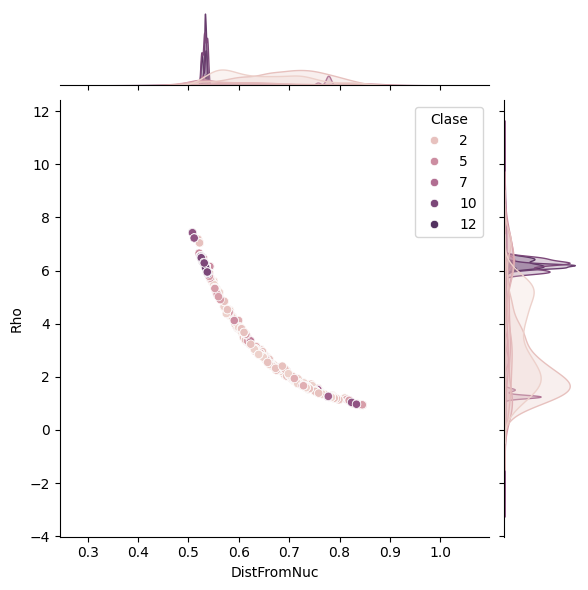

In [16]:
g = sns.jointplot(data=df_CP, x="DistFromNuc", y="Rho", hue="Clase")
g.set_axis_labels("DistFromNuc", "Rho")

In [17]:
# sns.pairplot(data=df_CP, hue="Clase")  #Demasiada pesado la imagen 

In [18]:
# sns.pairplot(data=df_atom, hue="clase") #Demasiada pesado la imagen 

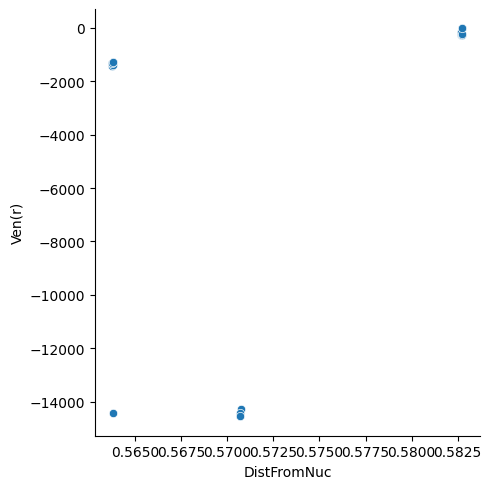

In [19]:
filter_CP = df_CP.loc[df_CP['Atom'] == "Co2_CP"] 
v = sns.relplot(data=filter_CP, x="DistFromNuc", y="Ven(r)")

## Representacion plana de graficas atomicas

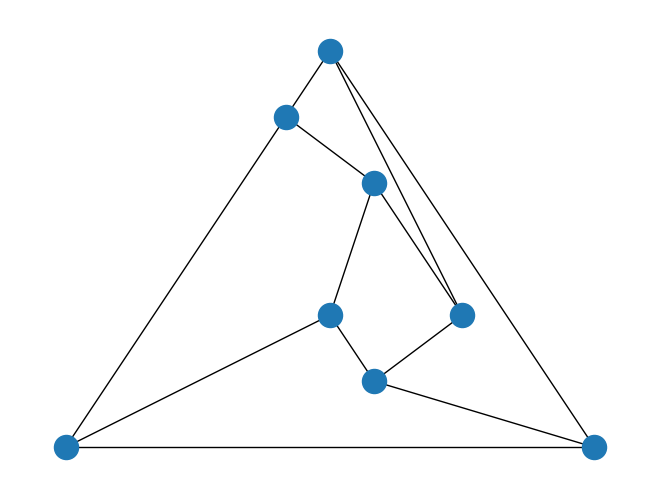

In [20]:
nx.draw_planar(grafica_Co2) # representacion plana de la clase  I

# PyTorch  Geometric

Preparacion de datos en el archivo datos_graficas_atomicas.py

## Construccion de Dataset personalizado.

In [21]:
#Creando nuestra data
class CustomGraphDataset(Dataset):
    def __init__(self, list_of_graphs, transform=None, pre_transform=None):
        super().__init__(None, transform, pre_transform)
        self.list_of_graphs = list_of_graphs  # Almacena la lista de grafcas

    def len(self):
        return len(self.list_of_graphs)

    def get(self, idx):
        return self.list_of_graphs[idx]  # Regresa el indice de la grafica :`idx`

dataset = CustomGraphDataset(list_of_graphs)

### Podando datos

In [46]:
def prune_edges(data, threshold):
    edge_index = data.edge_index
    edge_weight = data.edge_attr if hasattr(data, 'edge_attr') else None

    if edge_weight is not None:
        mask = edge_weight > threshold
        pruned_edge_index = edge_index[:, mask]
        pruned_edge_attr = edge_weight[mask] if edge_weight is not None else None
        data.edge_index = pruned_edge_index
        data.edge_attr = pruned_edge_attr
    return data

def process_dataset(dataset, method, **kwargs):
    return [method(graph, **kwargs) for graph in dataset]

### Normalizando graficas

In [48]:
all_features = torch.cat([data.x for data in dataset], dim=0)
# usando StandardScaler para normalizar el DATASET.
scaler = StandardScaler()
scaler.fit(all_features.numpy())  # Convierte a array de Numpy. 
# Aplicando la normalizacion a cada grafica del dataset.
for data in dataset:
    data.x = torch.tensor(scaler.transform(data.x.numpy()), dtype=torch.float)

# Normalizando las ARISTAS.
all_edge_weights = torch.cat([data.edge_attr for data in dataset if data.edge_attr is not None], dim=0)
# Usando Min-Max para escalar las aristas
edge_scaler = StandardScaler()
edge_scaler.fit(all_edge_weights.numpy())
# Aplicando la normalizacion de aristas.
for data in dataset:
    if data.edge_attr is not None:
        data.edge_attr = torch.tensor(edge_scaler.transform(data.edge_attr.numpy()), dtype=torch.float)

In [26]:
#Particionando dataset en entrenamiento,prueba,validacion.
train_graphs, test_graphs = train_test_split(list_of_graphs, test_size=0.2, random_state=42)
train_graphs, val_graphs = train_test_split(train_graphs, test_size=0.2, random_state=42)

train_dataset = CustomGraphDataset(train_graphs)
val_dataset = CustomGraphDataset(val_graphs)
test_dataset = CustomGraphDataset(test_graphs)

In [27]:
# Tamaño de los datos.
print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}, validation size: {len(val_dataset)}")

Train size: 44, Test size: 14, validation size: 11


In [49]:
#Cargando los datos a DataLoader.
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

## Graph Convolutional Network Convolution (GCNConv)

In [50]:
class BatchedGCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout=0.5):
        super(BatchedGCN, self).__init__()
        self.num_layers = num_layers
        self.dropout = dropout

        # Definiendo las capas del modelo GCN
        self.convs = torch.nn.ModuleList()
        self.convs.append(GCNConv(input_dim, hidden_dim))       # Input.
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))  # Hidden.
        self.convs.append(GCNConv(hidden_dim, output_dim))      # Output.

    def forward(self, x, edge_index, batch):
        # Pass a traves de cada capa.
       for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)                                      # Propagar los features
            if i != len(self.convs) - 1:                                 # Saltando la activation en la ultima capa.
                x = F.relu(x)                                            # Aplicando activacion ReLU.
                x = F.dropout(x, p=self.dropout, training=self.training) # Dropout
        # Global pooling para ouput a nivel grafica.
                x = global_mean_pool(x, batch)                           # Aggregar node features en los features de la grafica.
            return F.log_softmax(x, dim=1)                               # Log-softmax para classificacion.
    

### Modelo 

In [30]:
# Inicializando modelo,optimizador y la funcion de criterio.
model = BatchedGCN(input_dim=dataset.num_node_features, hidden_dim=32, output_dim=dataset.num_classes,num_layers=8).to(device)
optimizer = Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
criterion = torch.nn.CrossEntropyLoss()

In [31]:
# Configurar TensorBoard
#writer = SummaryWriter(log_dir='runs/gcn_batch_model')

# Obteniendo un lote del loader de entrenamiento.
#for batch in train_loader:
#    x, edge_index, batch_idx = batch.x, batch.edge_index, batch.batch
#    # Agregando la grafica del modelo a TensorBoard
#    writer.add_graph(model, (x, edge_index, batch_idx))
#    break
#writer.close()

#print("Agregado a TensorBoard.")

### Funcion de entrenamiento

In [51]:
# Definiendo la funcion de entrenamiento "train()".
def train(loader):
    model.train()
    total_loss = 0
    
    for data in loader:                                   # Iterando a traves de los lotes.
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)  # Forward pass
        loss = F.nll_loss(out, data.y)                    # Calculando la perdida.
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    return total_loss / len(loader)

### Funcion de evaluacion

In [52]:
# Definiendo la funcion de evaluacion "test()".
def test(loader):
    model.eval()
    correct = 0
    
    for data in loader:                                   # Iterando a traves de los lotes.
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=1)                          # predice la class
        correct += (pred == data.y).sum().item()
        
    return correct / len(loader.dataset)

### Bucle de entrenamiento

In [54]:
# Bucle de entrenamiento
for epoch in range(100):
    model.train()
    
    for batch in train_loader:
        # desempacando los datos
        x = batch.x                     # Node features
        edge_index = batch.edge_index   # indice de conexiones de aristas.
        batch_idx = batch.batch         # indice de lote.
        y = batch.y                     # Nivel grafica
        
        # moviendo los datos al CPU
        x, edge_index, batch_idx, y = x.to(device), edge_index.to(device), batch_idx.to(device), y.to(device)
        # Forward pass
        optimizer.zero_grad()
        out = model(x, edge_index, batch_idx)   # Forward pass 
        # Calculando la perdida
        loss = criterion(out, y)                # clasificacion a nivel grafica
        loss.backward()
        optimizer.step()

    
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 1.3236950635910034
Epoch 2, Loss: 2.443284034729004
Epoch 3, Loss: 3.327772855758667
Epoch 4, Loss: 2.8663253784179688
Epoch 5, Loss: 2.9153130054473877
Epoch 6, Loss: 1.3265608549118042
Epoch 7, Loss: 1.6742321252822876
Epoch 8, Loss: 2.105842113494873
Epoch 9, Loss: 2.0306966304779053
Epoch 10, Loss: 2.082160234451294
Epoch 11, Loss: 2.2543840408325195
Epoch 12, Loss: 1.9965534210205078
Epoch 13, Loss: 2.8347010612487793
Epoch 14, Loss: 3.0035464763641357
Epoch 15, Loss: 2.144176721572876
Epoch 16, Loss: 2.870452642440796
Epoch 17, Loss: 2.9217376708984375
Epoch 18, Loss: 2.0996086597442627
Epoch 19, Loss: 2.8344662189483643
Epoch 20, Loss: 1.4228588342666626
Epoch 21, Loss: 3.097233772277832
Epoch 22, Loss: 2.4899682998657227
Epoch 23, Loss: 2.508559226989746
Epoch 24, Loss: 1.7077354192733765
Epoch 25, Loss: 3.5496840476989746
Epoch 26, Loss: 3.2479138374328613
Epoch 27, Loss: 2.008338451385498
Epoch 28, Loss: 1.2786809206008911
Epoch 29, Loss: 1.664247989654541
Epoc

In [35]:
#print(model.state_dict()) # Imprimir paratos del modelo Parametros

### Validacion

In [55]:
def validate(loader):
    model.eval()                                              # Configurando modelo a modo valuacion.
    total_loss = 0
    correct = 0
    with torch.no_grad():                                     # No necesitamos gradiente.
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)  # Forward pass
            loss = F.nll_loss(out, data.y)                    # Calculando perdida
            total_loss += loss.item()
            pred = out.argmax(dim=1)                          # Obtiene clase predecida.
            correct += (pred == data.y).sum().item()          # Contando las predicciones correctas.
    accuracy = correct / len(loader.dataset)
    return total_loss / len(loader), accuracy

### Bucle de entrenamiento con validacion y graficando perdida

In [37]:
# Training loop with validation
#Para registrar. 
num_epochs = 101
train_losses = []
val_losses = []
best_val_acc = 0

for epoch in range(1, num_epochs + 1):
    train_loss = train(train_loader)
    val_loss, val_acc = validate(val_loader)
    test_acc = test(test_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(test_acc)

    if val_acc > best_val_acc:  # Save the best model based on validation accuracy
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pt')

    print(f"Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")
    

Epoch 001, Train Loss: 2.8988, Val Loss: 2.7984, Val Acc: 0.1818, Test Acc: 0.2857
Epoch 002, Train Loss: 2.8697, Val Loss: 2.7930, Val Acc: 0.1818, Test Acc: 0.2857
Epoch 003, Train Loss: 3.0055, Val Loss: 2.7876, Val Acc: 0.1818, Test Acc: 0.2857
Epoch 004, Train Loss: 2.8824, Val Loss: 2.7854, Val Acc: 0.1818, Test Acc: 0.2857
Epoch 005, Train Loss: 2.8297, Val Loss: 2.7931, Val Acc: 0.1818, Test Acc: 0.2857
Epoch 006, Train Loss: 2.7982, Val Loss: 2.8004, Val Acc: 0.1818, Test Acc: 0.2857
Epoch 007, Train Loss: 2.8537, Val Loss: 2.7992, Val Acc: 0.1818, Test Acc: 0.2857
Epoch 008, Train Loss: 2.8678, Val Loss: 2.7997, Val Acc: 0.1818, Test Acc: 0.2857
Epoch 009, Train Loss: 2.6782, Val Loss: 2.8012, Val Acc: 0.1818, Test Acc: 0.2857
Epoch 010, Train Loss: 2.8939, Val Loss: 2.7990, Val Acc: 0.1818, Test Acc: 0.2857
Epoch 011, Train Loss: 2.8567, Val Loss: 2.7985, Val Acc: 0.1818, Test Acc: 0.2857
Epoch 012, Train Loss: 2.9468, Val Loss: 2.7931, Val Acc: 0.1818, Test Acc: 0.2857
Epoc

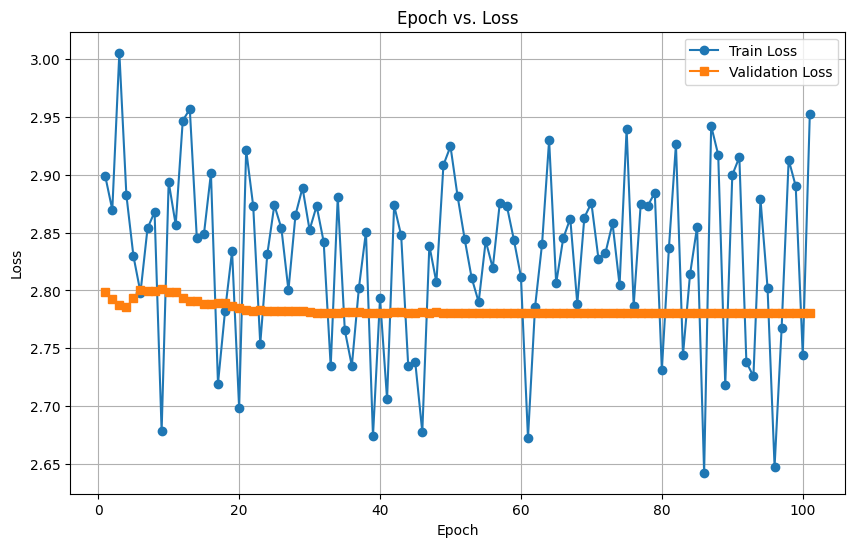

In [38]:
# Plotting the loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Epoch vs. Loss')
plt.legend()
plt.grid()
plt.show()

#### Explorando los Hiperparametros 

In [39]:
#Definiendo los paramentros a modificar
param_grid = {
    'hidden_channels': [32, 64, 128],
    'lr': [0.001, 0.01, 0.1],
    'weight_decay': [1e-4, 5e-4, 1e-3]
}

In [56]:
# Obtener la combinacion de hiperparametros
param_combinations = list(product(*param_grid.values()))

best_params = None
best_val_acc = 0.0

# Bucle de busqueda grid search
for params in param_combinations:
    hidden_channels, lr, weight_decay = params

    # Inicia el modelo y optimizacion
    model = BatchedGCN(input_dim=dataset.num_node_features, hidden_dim=32, output_dim=dataset.num_classes,num_layers=8).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Bucle de entrenamiento
    for epoch in range(50):  # epochs.
        train_loss = train(train_loader)

    # validacion
    val_loss, val_acc = validate(val_loader)

    # Mejor configuracion
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params

    print(f"Params: {params}, Validation Accuracy: {val_acc:.4f}")

print("Best Parameters:", best_params)
print("Best Validation Accuracy:", best_val_acc)

#Best Parameters: (32, 0.1, 0.0005)
#Best Validation Accuracy: 0.36363636363636365

Params: (32, 0.001, 0.0001), Validation Accuracy: 0.0000
Params: (32, 0.001, 0.0005), Validation Accuracy: 0.1818
Params: (32, 0.001, 0.001), Validation Accuracy: 0.1818
Params: (32, 0.01, 0.0001), Validation Accuracy: 0.1818
Params: (32, 0.01, 0.0005), Validation Accuracy: 0.2727
Params: (32, 0.01, 0.001), Validation Accuracy: 0.1818
Params: (32, 0.1, 0.0001), Validation Accuracy: 0.2727
Params: (32, 0.1, 0.0005), Validation Accuracy: 0.2727
Params: (32, 0.1, 0.001), Validation Accuracy: 0.2727
Params: (64, 0.001, 0.0001), Validation Accuracy: 0.1818
Params: (64, 0.001, 0.0005), Validation Accuracy: 0.1818
Params: (64, 0.001, 0.001), Validation Accuracy: 0.1818
Params: (64, 0.01, 0.0001), Validation Accuracy: 0.2727
Params: (64, 0.01, 0.0005), Validation Accuracy: 0.2727
Params: (64, 0.01, 0.001), Validation Accuracy: 0.1818
Params: (64, 0.1, 0.0001), Validation Accuracy: 0.2727
Params: (64, 0.1, 0.0005), Validation Accuracy: 0.1818
Params: (64, 0.1, 0.001), Validation Accuracy: 0.272

### Como aprende el modelo

In [41]:
for name, param in model.named_parameters():
    print(name, param.size())

convs.0.bias torch.Size([32])
convs.0.lin.weight torch.Size([32, 4])
convs.1.bias torch.Size([32])
convs.1.lin.weight torch.Size([32, 32])
convs.2.bias torch.Size([32])
convs.2.lin.weight torch.Size([32, 32])
convs.3.bias torch.Size([32])
convs.3.lin.weight torch.Size([32, 32])
convs.4.bias torch.Size([32])
convs.4.lin.weight torch.Size([32, 32])
convs.5.bias torch.Size([32])
convs.5.lin.weight torch.Size([32, 32])
convs.6.bias torch.Size([32])
convs.6.lin.weight torch.Size([32, 32])
convs.7.bias torch.Size([15])
convs.7.lin.weight torch.Size([15, 32])


## TensorBoard

In [42]:
notebook.list()

Known TensorBoard instances:
  - port 6009: logdir runs (started 9 days, 13:01:38 ago; pid 13704)
  - port 6008: logdir runs (started 12 days, 13:16:21 ago; pid 5912)
  - port 6006: logdir runs (started 13 days, 21:05:05 ago; pid 6556)
  - port 6006: logdir runs (started 13 days, 18:56:21 ago; pid 7808)
  - port 6007: logdir runs (started 13 days, 13:22:44 ago; pid 9636)


In [43]:
#Tarda en cargar, solo usar si queremos ver algo
#%tensorboard --logdir runs --port=6009 --host localhost   #Especifiquemos siempre el localhost,activar solo cuando se necesite.

# Cargando modelo

# Load the best model and test
model.load_state_dict(torch.load('best_model.pt'))
test_acc = test(test_loader)
print(f"Test Accuracy: {test_acc:.4f}")

In [44]:
for batch in train_loader:
    print(batch) 

DataBatch(x=[28, 4], edge_index=[2, 88], edge_attr=[88, 3], y=[4], graph_attr=[28], batch=[28], ptr=[5])
DataBatch(x=[26, 4], edge_index=[2, 80], edge_attr=[80, 3], y=[4], graph_attr=[28], batch=[26], ptr=[5])
DataBatch(x=[20, 4], edge_index=[2, 66], edge_attr=[76, 3], y=[4], graph_attr=[28], batch=[20], ptr=[5])
DataBatch(x=[24, 4], edge_index=[2, 76], edge_attr=[76, 3], y=[4], graph_attr=[27], batch=[24], ptr=[5])
DataBatch(x=[20, 4], edge_index=[2, 62], edge_attr=[70, 3], y=[4], graph_attr=[28], batch=[20], ptr=[5])
DataBatch(x=[18, 4], edge_index=[2, 48], edge_attr=[60, 3], y=[4], graph_attr=[28], batch=[18], ptr=[5])
DataBatch(x=[28, 4], edge_index=[2, 92], edge_attr=[92, 3], y=[4], graph_attr=[28], batch=[28], ptr=[5])
DataBatch(x=[22, 4], edge_index=[2, 66], edge_attr=[72, 3], y=[4], graph_attr=[28], batch=[22], ptr=[5])
DataBatch(x=[22, 4], edge_index=[2, 64], edge_attr=[80, 3], y=[4], graph_attr=[28], batch=[22], ptr=[5])
DataBatch(x=[22, 4], edge_index=[2, 64], edge_attr=[68,